<a href="https://colab.research.google.com/github/vadapallimaneesha/machine_learning-/blob/main/week10portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

this cell installs the pyspark and setups the enivornment

In [1]:
# ── Install PySpark (Colab only)
!pip install -q pyspark

# ── Standard library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# ── PySpark imports
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, lower, regexp_replace, trim, lit
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LinearSVC, LogisticRegression
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator
)
from pyspark.mllib.evaluation import MulticlassMetrics

# ── Plot style
plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('tab10')

print('All imports successful.')


All imports successful.


This cell initiallizes the spark session

In [2]:
spark = (
    SparkSession.builder
    .master('local[*]')
    .appName('IMDB_SVM_PortFolio_9')
    .config('spark.driver.memory', '4g')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')  # suppress INFO noise

print(f'    Spark {spark.version} started.')
print(f'    Master: {spark.sparkContext.master}')
print(f'    App:    {spark.sparkContext.appName}')


    Spark 4.0.4 started.
    Master: local[*]
    App:    IMDB_SVM_PortFolio_9


This cell uploads the dataset of IDMB Movies reviews of 50,000 of movie reviews

In [3]:
import os
import tarfile
import urllib.request
import pandas as pd
from pyspark.sql.types import StructType, StructField, StringType

# URL for the dataset
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
dataset_path = "/tmp/aclImdb_v1.tar.gz"
extracted_path = "/tmp/aclImdb" # This is the base directory where 'aclImdb' will be extracted

print(f"  Downloading dataset from {url}...")
urllib.request.urlretrieve(url, dataset_path)
print(f"  Dataset downloaded to {dataset_path}")

print(f"  Extracting dataset to {extracted_path}...")
with tarfile.open(dataset_path, "r:gz") as tar:
    # Extract all contents to /tmp/. The tarball itself contains a top-level 'aclImdb' directory.
    # So the full path to the extracted data will be /tmp/aclImdb
    tar.extractall(path="/tmp/")
print("  Dataset extracted.")

data = []
for split in ['train', 'test']:
    for sentiment in ['pos', 'neg']:
        # Correct path construction: os.path.join(extracted_path, split, sentiment)
        # Since extracted_path is /tmp/aclImdb, the subdirectories will be directly under it.
        path = os.path.join(extracted_path, split, sentiment)
        label = 'positive' if sentiment == 'pos' else 'negative'
        for file_name in os.listdir(path):
            if file_name.endswith('.txt'):
                file_path = os.path.join(path, file_name)
                with open(file_path, 'r', encoding='utf-8') as f:
                    review = f.read()
                    data.append({'review': review, 'sentiment': label})

print(f"  Loaded {len(data)} reviews into a list.")

# Create a Pandas DataFrame
pdf = pd.DataFrame(data)

# Shuffle the DataFrame for randomness (optional but good practice)
pdf = pdf.sample(frac=1, random_state=42).reset_index(drop=True)

# Convert Pandas DataFrame to Spark DataFrame
schema = StructType([
    StructField("review", StringType(), True),
    StructField("sentiment", StringType(), True)
])

# Ensure spark session is available
if 'spark' not in globals():
    raise NameError("SparkSession 'spark' is not defined. Please run previous setup cells.")

df = spark.createDataFrame(pdf, schema=schema)

print("\n  Spark DataFrame 'df' created successfully from downloaded data.")

  Dataset downloaded to /tmp/aclImdb_v1.tar.gz
  Extracting dataset to /tmp/aclImdb...


/tmp/ipykernel_1209/2676385529.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="/tmp/")


  Dataset extracted.
  Loaded 50000 reviews into a list.

  Spark DataFrame 'df' created successfully from downloaded data.


Load and inspect the pyspark.

In [4]:

print('── Schema ──────────────────────────────')
df.printSchema()

print('\n── Sample Rows ─────────────────────────')
df.show(5, truncate=80)

total_rows = df.count()
print(f'\n  Total rows: {total_rows:,}')


── Schema ──────────────────────────────
root
 |-- review: string (nullable = true)
 |-- sentiment: string (nullable = true)


── Sample Rows ─────────────────────────
+--------------------------------------------------------------------------------+---------+
|                                                                          review|sentiment|
+--------------------------------------------------------------------------------+---------+
|The best Batman movie of the 90's no doubt about it. This movie takes place i...| positive|
|This is a musical adaptation of Dicken's "Oliver Twist". For the most part, t...| positive|
|This is an excellent movie. As a Canadian who grew up with a rural lifestyle ...| positive|
|As we all know a romantic comedy is the genre with the ending already known. ...| positive|
|Let Freedom Ring was probably made with the best of intentions, but it sends ...| negative|
+--------------------------------------------------------------------------------+------

This cell shows the exploratory data analysis

  Using text column: "review"   |   label column: "sentiment"


/tmp/ipykernel_1209/231964692.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_dist_pd, x=label_col, y='count', ax=axes[0],


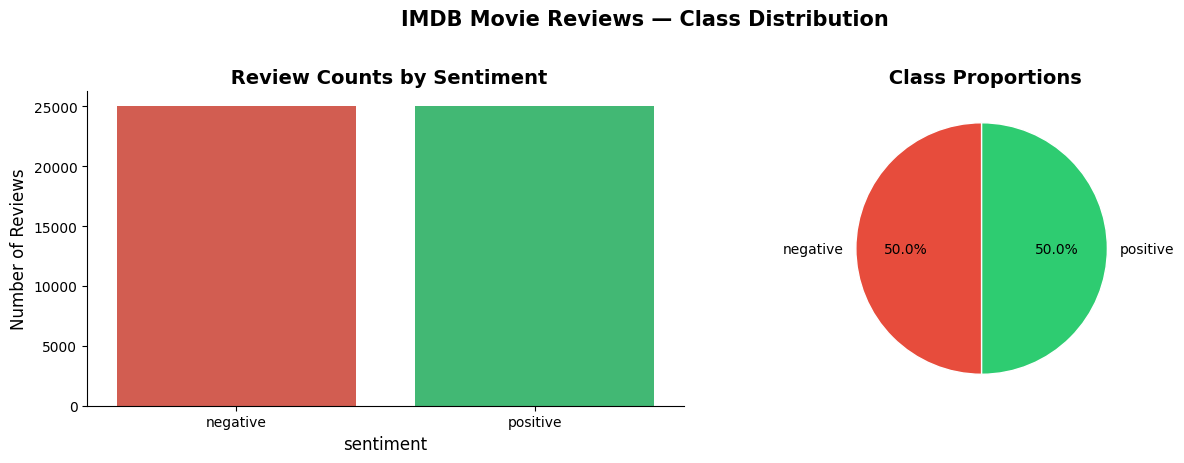

sentiment  count
 negative  25000
 positive  25000


In [5]:
# ── Resolve label / text columns (robust to minor naming differences)
label_candidates = ['sentiment', 'label', 'Sentiment']
text_candidates  = ['review', 'text', 'Review']

label_col = next((c for c in label_candidates if c in df.columns), None)
text_col  = next((c for c in text_candidates  if c in df.columns), None)

if label_col is None or text_col is None:
    raise ValueError(f'Could not resolve columns. Available: {df.columns}')

print(f'  Using text column: "{text_col}"   |   label column: "{label_col}"')

# ── Class balance
class_dist_pd = df.groupBy(label_col).count().orderBy(label_col).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=class_dist_pd, x=label_col, y='count', ax=axes[0],
            palette=['#e74c3c', '#2ecc71'])
axes[0].set_title(' Review Counts by Sentiment', fontweight='bold')
axes[0].set_ylabel('Number of Reviews')

axes[1].pie(
    class_dist_pd['count'], labels=class_dist_pd[label_col], autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'], wedgeprops={'edgecolor': 'white'}, startangle=90
)
axes[1].set_title(' Class Proportions', fontweight='bold')

plt.suptitle('IMDB Movie Reviews — Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(class_dist_pd.to_string(index=False))


This cell shows Text preprocessing and label engineering

In [6]:
df2 = df.select(
    col(text_col).cast('string').alias('text_raw'),
    col(label_col).cast('string').alias('label_raw')
).na.drop()

# ── Binary label: positive -> 1.0, negative -> 0.0
df2 = df2.withColumn(
    'label',
    when(lower(col('label_raw')) == 'positive', lit(1.0)).otherwise(lit(0.0))
)

# ── Text cleaning (HTML strip -> lowercase -> non-alpha strip -> whitespace collapse)
df2 = (
    df2
    .withColumn('text', regexp_replace(col('text_raw'), r'<br\s*/?>', ' '))   # strip HTML line breaks
    .withColumn('text', regexp_replace(col('text'), r'<.*?>', ' '))          # strip any other tags
    .withColumn('text', lower(col('text')))
    .withColumn('text', regexp_replace(col('text'), r"[^a-z\s]", ' '))
    .withColumn('text', regexp_replace(col('text'), r'\s+', ' '))
    .withColumn('text', trim(col('text')))
    .select('text', 'label')
    .na.drop()
    .filter(col('text') != '')
)

print('── Cleaned Sample ──────────────────────────────')
df2.show(4, truncate=80)

print('\n── Binary Label Distribution ──────────────────────')
label_dist = df2.groupBy('label').count().orderBy('label').toPandas()
label_dist['class'] = label_dist['label'].map({0.0: 'Negative', 1.0: 'Positive'})
print(label_dist[['class', 'count']].to_string(index=False))
print('\n  Preprocessing complete.')


── Cleaned Sample ──────────────────────────────
+--------------------------------------------------------------------------------+-----+
|                                                                            text|label|
+--------------------------------------------------------------------------------+-----+
|the best batman movie of the s no doubt about it this movie takes place in a ...|  1.0|
|this is a musical adaptation of dicken s oliver twist for the most part the o...|  1.0|
|this is an excellent movie as a canadian who grew up with a rural lifestyle m...|  1.0|
|as we all know a romantic comedy is the genre with the ending already known t...|  1.0|
+--------------------------------------------------------------------------------+-----+
only showing top 4 rows

── Binary Label Distribution ──────────────────────
   class  count
Negative  25000
Positive  25000

  Preprocessing complete.


This cell tries to split and train the dataset.

  Train samples : 40,137  (80.3%)
  Test  samples : 9,863  (19.7%)


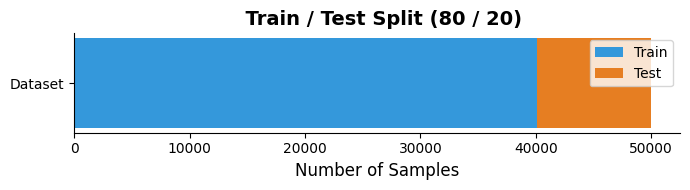

In [7]:
train_df, test_df = df2.randomSplit([0.8, 0.2], seed=42)

n_train = train_df.count()
n_test  = test_df.count()

print(f'  Train samples : {n_train:,}  ({n_train/(n_train+n_test)*100:.1f}%)')
print(f'  Test  samples : {n_test:,}  ({n_test/(n_train+n_test)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 2))
ax.barh(['Dataset'], [n_train], color='#3498db', label='Train')
ax.barh(['Dataset'], [n_test],  left=[n_train], color='#e67e22', label='Test')
ax.set_xlabel('Number of Samples')
ax.set_title('  Train / Test Split (80 / 20)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


this cell shows the feature engineering of TF-IDF

In [8]:
tokenizer = Tokenizer(inputCol='text', outputCol='tokens')
stop_rm   = StopWordsRemover(inputCol='tokens', outputCol='filtered')
hash_tf   = HashingTF(inputCol='filtered', outputCol='tf', numFeatures=2**18)  # 262,144
idf       = IDF(inputCol='tf', outputCol='features')

featurizer = Pipeline(stages=[tokenizer, stop_rm, hash_tf, idf])
feat_model = featurizer.fit(train_df)

train_fe = feat_model.transform(train_df)
test_fe  = feat_model.transform(test_df)

print('  TF-IDF vectors created.')
print(f'    Feature dimensions: {hash_tf.getNumFeatures():,}')
print('\n── Sample feature vectors (sparse) ──────────────────────')
train_fe.select('text', 'features').show(3, truncate=60)


  TF-IDF vectors created.
    Feature dimensions: 262,144

── Sample feature vectors (sparse) ──────────────────────
+------------------------------------------------------------+------------------------------------------------------------+
|                                                        text|                                                    features|
+------------------------------------------------------------+------------------------------------------------------------+
|a bad movie about a bad movie is that original or what if...|(262144,[6558,17291,19698,22116,32665,36881,37895,40299,4...|
|a bad movie but with one reel that is worth savoring for ...|(262144,[6946,17291,17734,21823,24346,27295,50740,51247,5...|
|a bad rip off attempt on seven complete with sub second g...|(262144,[8449,8538,8804,9413,11275,14636,15867,17252,2164...|
+------------------------------------------------------------+------------------------------------------------------------+
only showing to

This cell shows the model training of the dataset as Linear SVM

In [9]:
svm = LinearSVC(featuresCol='features', labelCol='label', maxIter=50, regParam=0.1)

print('  Training Linear SVM...')
t0 = time.time()
pipeline_svm = Pipeline(stages=[tokenizer, stop_rm, hash_tf, idf, svm])
svm_model    = pipeline_svm.fit(train_df)
svm_pred     = svm_model.transform(test_df)
svm_time     = time.time() - t0
print(f'Done in {svm_time:.1f}s')


  Training Linear SVM...
Done in 80.9s


In [10]:
# ── Optional reference benchmark: Logistic Regression
lr = LogisticRegression(featuresCol='features', labelCol='label', maxIter=50)

print(' Training Logistic Regression (reference benchmark only)...')
t0 = time.time()
pipeline_lr = Pipeline(stages=[tokenizer, stop_rm, hash_tf, idf, lr])
lr_model    = pipeline_lr.fit(train_df)
lr_pred     = lr_model.transform(test_df)
lr_time     = time.time() - t0
print(f'Done in {lr_time:.1f}s')


 Training Logistic Regression (reference benchmark only)...
Done in 60.9s


This cell shows the model evaluation


══════════════ Evaluation Results ══════════════

  Linear SVM (primary)
    Accuracy  : 0.8905
    Precision : 0.8909
    Recall    : 0.8905
    F1 Score  : 0.8905
    AUC-ROC   : 0.9495
    Train Time: 80.9s

  Logistic Regression (reference)
    Accuracy  : 0.8566
    Precision : 0.8569
    Recall    : 0.8566
    F1 Score  : 0.8566
    AUC-ROC   : 0.9191
    Train Time: 60.9s


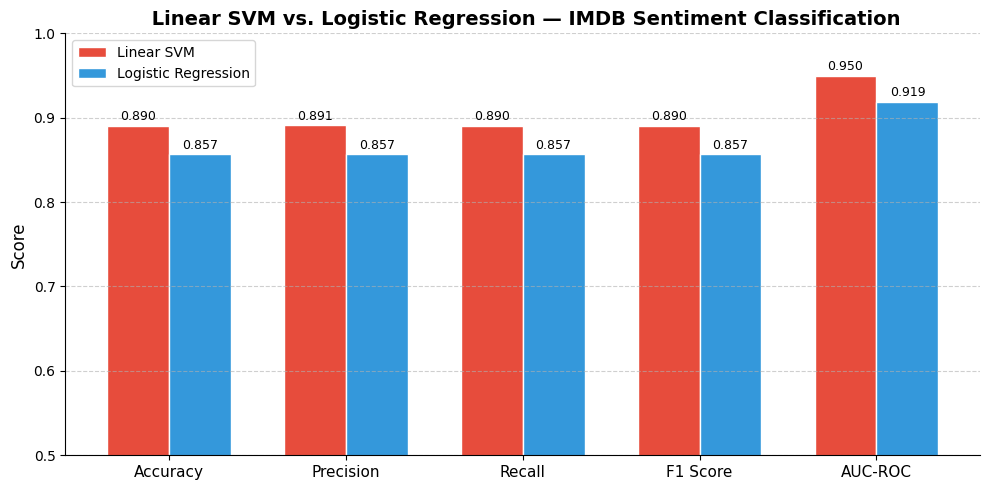

In [11]:
acc_eval  = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
f1_eval   = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1')
prec_eval = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedPrecision')
rec_eval  = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedRecall')
auc_eval  = BinaryClassificationEvaluator(labelCol='label', rawPredictionCol='rawPrediction', metricName='areaUnderROC')

svm_acc  = acc_eval.evaluate(svm_pred)
svm_f1   = f1_eval.evaluate(svm_pred)
svm_prec = prec_eval.evaluate(svm_pred)
svm_rec  = rec_eval.evaluate(svm_pred)
svm_auc  = auc_eval.evaluate(svm_pred)

lr_acc  = acc_eval.evaluate(lr_pred)
lr_f1   = f1_eval.evaluate(lr_pred)
lr_prec = prec_eval.evaluate(lr_pred)
lr_rec  = rec_eval.evaluate(lr_pred)
lr_auc  = auc_eval.evaluate(lr_pred)

results = pd.DataFrame({
    'Model':          ['Linear SVM (primary)', 'Logistic Regression (reference)'],
    'Accuracy':       [svm_acc,  lr_acc],
    'Precision':      [svm_prec, lr_prec],
    'Recall':         [svm_rec,  lr_rec],
    'F1 Score':       [svm_f1,   lr_f1],
    'AUC-ROC':        [svm_auc,  lr_auc],
    'Train Time (s)': [svm_time, lr_time],
})

print('\n══════════════ Evaluation Results ══════════════')
for _, row in results.iterrows():
    print(f"\n  {row['Model']}")
    print(f"    Accuracy  : {row['Accuracy']:.4f}")
    print(f"    Precision : {row['Precision']:.4f}")
    print(f"    Recall    : {row['Recall']:.4f}")
    print(f"    F1 Score  : {row['F1 Score']:.4f}")
    print(f"    AUC-ROC   : {row['AUC-ROC']:.4f}")
    print(f"    Train Time: {row['Train Time (s)']:.1f}s")

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, [svm_acc, svm_prec, svm_rec, svm_f1, svm_auc], width,
               label='Linear SVM', color='#e74c3c', edgecolor='white')
bars2 = ax.bar(x + width/2, [lr_acc, lr_prec, lr_rec, lr_f1, lr_auc], width,
               label='Logistic Regression', color='#3498db', edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0.5, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylabel('Score')
ax.set_title(' Linear SVM vs. Logistic Regression — IMDB Sentiment Classification', fontweight='bold')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


This cell shows the confusion matrix

/usr/local/lib/python3.13/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


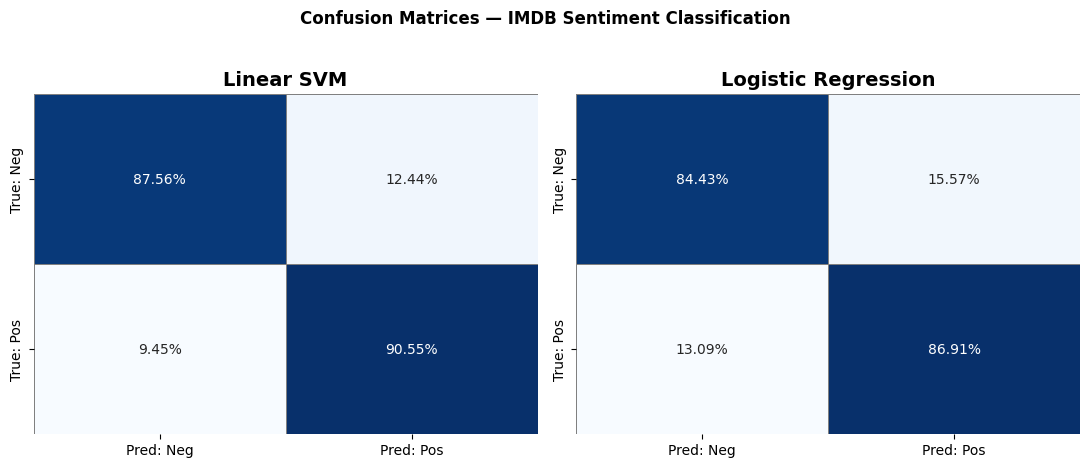


Linear SVM — raw counts (TN  FP / FN  TP):
[[4335  616]
 [ 464 4448]]

Logistic Regression — raw counts (TN  FP / FN  TP):
[[4180  771]
 [ 643 4269]]


In [12]:
def plot_confusion_matrix(pred_df, model_name, ax):
    rdd = pred_df.select('prediction', 'label').rdd.map(lambda r: (float(r[0]), float(r[1])))
    cm_metrics = MulticlassMetrics(rdd)
    cm = cm_metrics.confusionMatrix().toArray()
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=ax,
        xticklabels=['Pred: Neg', 'Pred: Pos'],
        yticklabels=['True: Neg', 'True: Pos'],
        linewidths=0.5, linecolor='grey', cbar=False
    )
    ax.set_title(model_name, fontweight='bold')
    return cm

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
cm_svm = plot_confusion_matrix(svm_pred, 'Linear SVM', axes[0])
cm_lr  = plot_confusion_matrix(lr_pred,  'Logistic Regression', axes[1])
plt.suptitle('Confusion Matrices — IMDB Sentiment Classification', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('\nLinear SVM — raw counts (TN  FP / FN  TP):')
print(cm_svm.astype(int))
print('\nLogistic Regression — raw counts (TN  FP / FN  TP):')
print(cm_lr.astype(int))


This cell shows the ROC curve of the data of Linear SVM,Logistic regression,Random.

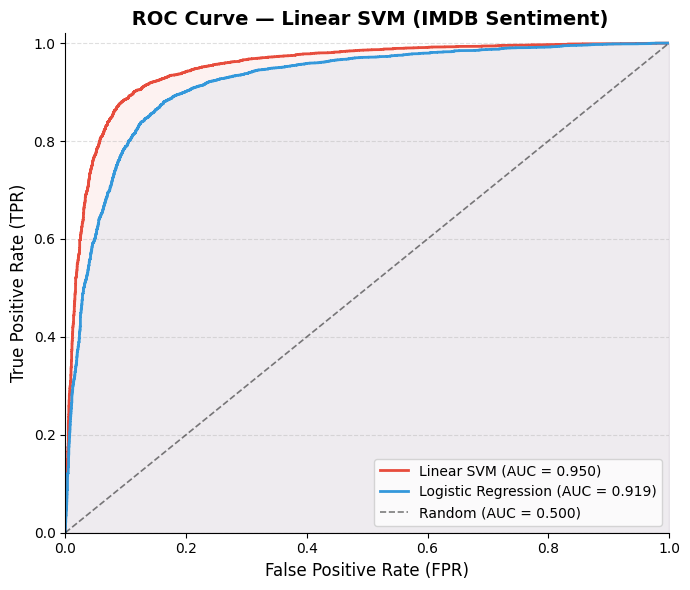

In [13]:
def compute_roc(pred_df, pos_class_idx=1):
    roc_pd = (
        pred_df.select('rawPrediction', 'label').rdd
        .map(lambda r: (float(r['rawPrediction'][pos_class_idx]), float(r['label'])))
        .toDF(['score', 'label'])
        .toPandas()
        .sort_values('score', ascending=False)
    )
    P  = (roc_pd['label'] == 1.0).sum()
    Nn = (roc_pd['label'] == 0.0).sum()
    tpr, fpr, tp, fp, prev = [], [], 0, 0, None
    for score, lab in zip(roc_pd['score'], roc_pd['label']):
        if prev is None or score != prev:
            tpr.append(tp / P if P else 0.0)
            fpr.append(fp / Nn if Nn else 0.0)
            prev = score
        if lab == 1.0: tp += 1
        else:          fp += 1
    tpr.append(1.0); fpr.append(1.0)
    return np.array(fpr), np.array(tpr)

fpr_svm, tpr_svm = compute_roc(svm_pred)
fpr_lr,  tpr_lr  = compute_roc(lr_pred)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_svm, tpr_svm, color='#e74c3c', lw=2, label=f'Linear SVM (AUC = {svm_auc:.3f})')
ax.plot(fpr_lr,  tpr_lr,  color='#3498db', lw=2, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5, label='Random (AUC = 0.500)')

ax.fill_between(fpr_svm, tpr_svm, alpha=0.07, color='#e74c3c')
ax.fill_between(fpr_lr,  tpr_lr,  alpha=0.07, color='#3498db')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax.set_title(' ROC Curve — Linear SVM (IMDB Sentiment)', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
